###### 132_1_practical_lcm_due_date_check_answer.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [3]:
#cell2

df_defect = pd.read_csv("dataset/lcm_due_date_dirty.csv")
df_defect

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status
0,D001,SUS,Honda,J69P,Buck-IC,3,2026/07/01 09:15,2026/07/01 10:05,2026/07/05 17:00,2026/07/03 17:30,回答済
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済
2,D003,GSE,Mitsubishi,310D,NTF,1,20260703 101500,20260703 113000,20260708 170000,20260708 153000,回答済
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026/07/05 08:40,2026/07/05 09:25,2026/07/09 17:00,NaN,調査中
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済
5,D006,WSE,Honda,J69P,NTF,1,20260710 091000,20260710 100500,20260713 170000,NaN,調査中
6,D007,GSE,Honda,310D,Buck-IC,5,2026/08/01 15:20,2026/08/01 16:00,2026/08/05 17:00,2026/08/06 09:30,回答済
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaN,調査中
8,D009,SUS,Honda,310D,Coil,3,20260805 083000,20260805 091500,20260809 170000,20260807 174500,回答済
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026/08/07 10:30,2026/08/07 11:10,2026/08/10 17:00,2026/08/14 13:00,回答済


In [4]:
df_defect.dtypes

defect_id          object
site               object
customer           object
model              object
defect_category    object
defect_qty          int64
occ_at             object
received_at        object
due_at             object
answered_at        object
cm_status          object
dtype: object

In [5]:
date_columns = [
    "occ_at",
    "received_at",
    "due_at",
    "answered_at",
]

for col in date_columns:
    df_defect[col] = pd.to_datetime(
        df_defect[col],
        format="mixed",
        errors="coerce",
    )
df_defect

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済
5,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中
6,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaT,調査中
8,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済


In [7]:
df_defect.dtypes

defect_id                  object
site                       object
customer                   object
model                      object
defect_category            object
defect_qty                  int64
occ_at             datetime64[ns]
received_at        datetime64[ns]
due_at             datetime64[ns]
answered_at        datetime64[ns]
cm_status                  object
dtype: object

In [8]:
df_defect["occ_month"] = (
    df_defect["occ_at"]
    .dt.to_period("M")
    .astype(str)
)
df_defect

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07
5,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中,2026-07
6,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済,2026-08
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaT,調査中,2026-08
8,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済,2026-08
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済,2026-08


In [9]:
#cell 7
df_defect["answered_flag"] = df_defect["answered_at"].notna()
df_defect.head()

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07,True
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07,True
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07,True
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07,False
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07,True


In [10]:
df_answered = df_defect[
    df_defect["answered_flag"]
].copy()
df_answered

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07,True
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07,True
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07,True
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07,True
6,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済,2026-08,True
8,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済,2026-08,True
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済,2026-08,True
11,D012,SUS,Mitsubishi,J69P,NTF,1,2026-08-12 13:30:00,2026-08-12 14:20:00,2026-08-16 17:00:00,2026-08-15 15:10:00,回答済,2026-08,True


In [11]:
df_not_answered = df_defect[
    ~df_defect["answered_flag"]
].copy()
df_not_answered

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07,False
5,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中,2026-07,False
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaT,調査中,2026-08,False
10,D011,GSE,Honda,J69P,Coil,1,2026-08-10 09:00:00,2026-08-10 10:00:00,2026-08-14 17:00:00,NaT,調査中,2026-08,False


In [12]:
df_answered["response_days"] = (
    df_answered["answered_at"] - df_answered["occ_at"]
).dt.days
df_answered

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag,response_days
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07,True,2
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07,True,3
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07,True,5
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07,True,2
6,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済,2026-08,True,4
8,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済,2026-08,True,2
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済,2026-08,True,7
11,D012,SUS,Mitsubishi,J69P,NTF,1,2026-08-12 13:30:00,2026-08-12 14:20:00,2026-08-16 17:00:00,2026-08-15 15:10:00,回答済,2026-08,True,3


In [13]:
df_answered["over_due_flag"] = (
    df_answered["answered_at"] > df_answered["due_at"]
)
df_answered

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag,response_days,over_due_flag
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07,True,2,False
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07,True,3,True
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07,True,5,False
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07,True,2,False
6,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済,2026-08,True,4,True
8,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済,2026-08,True,2,False
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済,2026-08,True,7,True
11,D012,SUS,Mitsubishi,J69P,NTF,1,2026-08-12 13:30:00,2026-08-12 14:20:00,2026-08-16 17:00:00,2026-08-15 15:10:00,回答済,2026-08,True,3,False


In [14]:
today = pd.Timestamp("2026-08-15")
today

Timestamp('2026-08-15 00:00:00')

In [15]:
df_not_answered["elapsed_days"] = (
    today - df_not_answered["occ_at"]
).dt.days
df_not_answered

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag,elapsed_days
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07,False,40
5,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中,2026-07,False,35
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaT,調査中,2026-08,False,11
10,D011,GSE,Honda,J69P,Coil,1,2026-08-10 09:00:00,2026-08-10 10:00:00,2026-08-14 17:00:00,NaT,調査中,2026-08,False,4


In [16]:
df_not_answered["over_due_flag"] = (
    today > df_not_answered["due_at"]
)
df_not_answered

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag,elapsed_days,over_due_flag
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07,False,40,True
5,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中,2026-07,False,35,True
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaT,調査中,2026-08,False,11,True
10,D011,GSE,Honda,J69P,Coil,1,2026-08-10 09:00:00,2026-08-10 10:00:00,2026-08-14 17:00:00,NaT,調査中,2026-08,False,4,True


In [17]:
df_checked = pd.concat(
    [
        df_answered,
        df_not_answered,
    ],
    ignore_index=True
)
df_checked

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag,response_days,over_due_flag,elapsed_days
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07,True,2.0,False,NaN
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07,True,3.0,True,NaN
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07,True,5.0,False,NaN
3,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07,True,2.0,False,NaN
4,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済,2026-08,True,4.0,True,NaN
5,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済,2026-08,True,2.0,False,NaN
6,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済,2026-08,True,7.0,True,NaN
7,D012,SUS,Mitsubishi,J69P,NTF,1,2026-08-12 13:30:00,2026-08-12 14:20:00,2026-08-16 17:00:00,2026-08-15 15:10:00,回答済,2026-08,True,3.0,False,NaN
8,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07,False,NaN,True,40.0
9,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中,2026-07,False,NaN,True,35.0


In [18]:
df_checked = df_checked.sort_values(
    "defect_id",
).reset_index(drop=True)
df_checked

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag,response_days,over_due_flag,elapsed_days
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07,True,2.0,False,NaN
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07,True,3.0,True,NaN
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07,True,5.0,False,NaN
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07,False,NaN,True,40.0
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07,True,2.0,False,NaN
5,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中,2026-07,False,NaN,True,35.0
6,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済,2026-08,True,4.0,True,NaN
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaT,調査中,2026-08,False,NaN,True,11.0
8,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済,2026-08,True,2.0,False,NaN
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済,2026-08,True,7.0,True,NaN


In [21]:
df_checked["over_due_reason"] = ""
df_checked

df_checked.loc[
    df_checked["answered_flag"]
    & df_checked["over_due_flag"],
    "over_due_reason",
] = "回答遅延"
df_checked

df_checked.loc[
    ~df_checked["answered_flag"]
    & df_checked["over_due_flag"],
    "over_due_reason",
] = "未回答期限超過"

df_checked

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,received_at,due_at,answered_at,cm_status,occ_month,answered_flag,response_days,over_due_flag,elapsed_days,over_due_reason
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,2026-07-01 10:05:00,2026-07-05 17:00:00,2026-07-03 17:30:00,回答済,2026-07,True,2.0,False,NaN,
1,D002,WSE,Honda,310D,Coil,1,2026-07-02 14:30:00,2026-07-02 15:10:00,2026-07-05 17:00:00,2026-07-06 11:20:00,回答済,2026-07,True,3.0,True,NaN,回答遅延
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-03 10:15:00,2026-07-03 11:30:00,2026-07-08 17:00:00,2026-07-08 15:30:00,回答済,2026-07,True,5.0,False,NaN,
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-05 08:40:00,2026-07-05 09:25:00,2026-07-09 17:00:00,NaT,調査中,2026-07,False,NaN,True,40.0,未回答期限超過
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-08 13:00:00,2026-07-08 14:00:00,2026-07-12 17:00:00,2026-07-10 16:45:00,回答済,2026-07,True,2.0,False,NaN,
5,D006,WSE,Honda,J69P,NTF,1,2026-07-10 09:10:00,2026-07-10 10:05:00,2026-07-13 17:00:00,NaT,調査中,2026-07,False,NaN,True,35.0,未回答期限超過
6,D007,GSE,Honda,310D,Buck-IC,5,2026-08-01 15:20:00,2026-08-01 16:00:00,2026-08-05 17:00:00,2026-08-06 09:30:00,回答済,2026-08,True,4.0,True,NaN,回答遅延
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-08-03 11:10:00,2026-08-03 11:45:00,2026-08-07 17:00:00,NaT,調査中,2026-08,False,NaN,True,11.0,未回答期限超過
8,D009,SUS,Honda,310D,Coil,3,2026-08-05 08:30:00,2026-08-05 09:15:00,2026-08-09 17:00:00,2026-08-07 17:45:00,回答済,2026-08,True,2.0,False,NaN,
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-07 10:30:00,2026-08-07 11:10:00,2026-08-10 17:00:00,2026-08-14 13:00:00,回答済,2026-08,True,7.0,True,NaN,回答遅延


In [23]:
df_over_due = df_checked[
    df_checked["over_due_flag"]
][
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "defect_category",
        "occ_at",
        "answered_at",
        "cm_status",
        "over_due_flag",
        "over_due_reason",
    ]
].copy()
df_over_due

,defect_id,site,customer,model,defect_category,occ_at,answered_at,cm_status,over_due_flag,over_due_reason
1,D002,WSE,Honda,310D,Coil,2026-07-02 14:30:00,2026-07-06 11:20:00,回答済,True,回答遅延
3,D004,MELMB,Honda,J69P,Buck-IC,2026-07-05 08:40:00,NaT,調査中,True,未回答期限超過
5,D006,WSE,Honda,J69P,NTF,2026-07-10 09:10:00,NaT,調査中,True,未回答期限超過
6,D007,GSE,Honda,310D,Buck-IC,2026-08-01 15:20:00,2026-08-06 09:30:00,回答済,True,回答遅延
7,D008,MELMB,Mitsubishi,J69P,Coil,2026-08-03 11:10:00,NaT,調査中,True,未回答期限超過
9,D010,WSE,Mitsubishi,310D,Buck-IC,2026-08-07 10:30:00,2026-08-14 13:00:00,回答済,True,回答遅延
10,D011,GSE,Honda,J69P,Coil,2026-08-10 09:00:00,NaT,調査中,True,未回答期限超過


In [27]:
df_month_over_due = df_checked.groupby(
    "occ_month",
    as_index=False,
)["over_due_flag"].sum()

df_month_over_due

df_month_over_due = df_month_over_due.rename(
    columns={
        "over_due_flag": "over_due_count",
    }
)
df_month_over_due
df_month_over_due["over_due_count"] = (
    df_month_over_due["over_due_count"].astype(int)
)
df_month_over_due.dtypes

occ_month         object
over_due_count     int64
dtype: object

In [33]:
#cell 19
df_site_over_due = df_checked.groupby(
    "site",
    as_index=False,
)["over_due_flag"].sum()
df_site_over_due

df_site_over_due = df_site_over_due.rename(
    columns={
        "over_due_flag": "over_due_count",
    }
)
df_site_over_due
print(df_site_over_due.dtypes)

df_site_over_due["over_due_count"] = (
    df_site_over_due["over_due_count"].astype(int)
)
df_site_over_due.dtypes

df_site_over_dure = df_site_over_due.sort_values(
    [
        "over_due_count",
        "site",
    ],
    ascending=[False, True],
).reset_index(drop=True)
df_site_over_due

site              object
over_due_count     int64
dtype: object


,site,over_due_count
0,GSE,2
1,MELMB,2
2,SUS,0
3,WSE,3


In [34]:
total_count = len(df_checked)

In [35]:
total_count

12

In [37]:
over_due_count = df_checked["over_due_flag"].sum()


In [38]:
over_due_rate = round(
    over_due_count / total_count * 100,
    1,
)

total_count, over_due_count, over_due_rate

(12, np.int64(7), np.float64(58.3))

In [44]:
df_site_over_due_rate = df_checked.groupby(
    "site",
    as_index=False,
).agg(
    total_count=("defect_id", "count"),
    over_due_count=("over_due_flag", "sum"),
)
df_site_over_due_rate

df_site_over_due_rate["over_due_count"] = (
    df_site_over_due_rate["over_due_count"].astype(int)
)
df_site_over_due_rate

df_site_over_due_rate["over_due_rate"] = (
    df_site_over_due_rate["over_due_count"]
    / df_site_over_due_rate["total_count"]
    * 100
).round(1)
df_site_over_due_rate

df_site_over_due_rate = df_site_over_due_rate.sort_values(
    [
        "over_due_rate",
        "over_due_count",
        "site",
    ],
    ascending=[
        False,
        False,
        True,
    ],
).reset_index(drop=True)
df_site_over_due_rate

,site,total_count,over_due_count,over_due_rate
0,WSE,3,3,100.0
1,MELMB,2,2,100.0
2,GSE,3,2,66.7
3,SUS,4,0,0.0


In [45]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

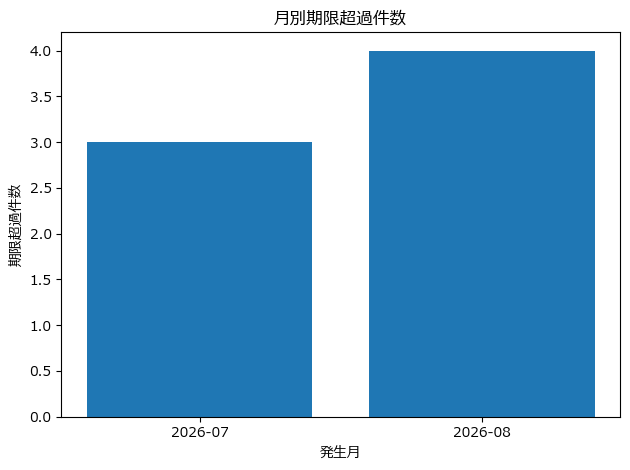

In [49]:
plt.bar(
    df_month_over_due["occ_month"],
    df_month_over_due["over_due_count"]
)

plt.title("月別期限超過件数")
plt.xlabel("発生月")
plt.ylabel("期限超過件数")

plt.tight_layout()
plt.show()
